# MCDI504 - Machine Learning I
## Fase 2 - Búsqueda y recopilación de información
### Implementación de modelos de regresión supervisada

**Curso:** MCDI504 - Machine Learning I  
**Docente:** Dr. David Ruete Zúñiga  
**Integrantes:** Luis Díaz Giral, Gonzalo Bouldres y Eduardo Contreras  
**Grupo:** 6  
**Programa:** Magíster en Ciencia de Datos e Inteligencia Artificial  
**Universidad:** Universidad Andrés Bello  
**Fecha:** 14 de agosto de 2026  
**Notebook:** `F2_Regresion.ipynb`  
**Conjunto de datos:** California Housing  
**Variable objetivo:** `MedHouseVal`

## 1. Introducción y contextualización

California Housing contiene información demográfica, habitacional y geográfica de distritos censales de California. El problema se formula como aprendizaje supervisado de regresión porque la variable objetivo `MedHouseVal` es numérica y continua.

El objetivo analítico de esta fase es preparar los datos e implementar tres modelos principales: regresión lineal simple, árbol de decisión y red neuronal MLP. Su desempeño se calculará sobre un conjunto de prueba independiente mediante MSE, RMSE y R².

## 2. Reproducibilidad y entorno

Se utiliza `random_state=42` en la partición y en los modelos estocásticos. Durante la ejecución se registran las versiones principales del entorno. Las figuras se guardan en `Semana2/figures` y los resultados tabulares en `Semana2/outputs`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def localizar_semana2(directorio_actual: Path) -> Path:
    directorio_actual = directorio_actual.resolve()
    candidatos = [
        directorio_actual,
        directorio_actual.parent,
        directorio_actual / 'Semana2',
        directorio_actual.parent / 'Semana2',
    ]
    for candidato in candidatos:
        if candidato.name == 'Semana2' and (candidato / 'notebook').exists():
            return candidato
        anidado = candidato / 'Semana2'
        if anidado.exists() and (anidado / 'notebook').exists():
            return anidado
    raise FileNotFoundError(
        'No fue posible localizar la carpeta Semana2. '
        'Inicie Jupyter desde la raíz del repositorio, Semana2 o Semana2/notebook.'
    )

SEMANA2_DIR = localizar_semana2(Path.cwd())
FIG_DIR = SEMANA2_DIR / 'figures'
OUT_DIR = SEMANA2_DIR / 'outputs'
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

versiones = pd.DataFrame({
    'Componente': ['Python', 'NumPy', 'pandas', 'scikit-learn', 'Matplotlib'],
    'Version': [
        sys.version.split()[0],
        np.__version__,
        pd.__version__,
        sklearn.__version__,
        matplotlib.__version__,
    ],
})

display(versiones)
versiones.to_csv(OUT_DIR / 'versiones_entorno.csv', index=False)

,Componente,Version
0,Python,3.12.4
1,NumPy,1.26.4
2,pandas,2.2.2
3,scikit-learn,1.4.2
4,Matplotlib,3.8.4


## 3. Descripción del conjunto de datos y preprocesamiento

### 3.1 Carga y estructura del dataset

El conjunto se carga mediante `fetch_california_housing(as_frame=True)`. Se revisan dimensiones, primeras observaciones y tipos de datos.

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

print('Dimensión del dataset:', df.shape)
display(df.head())
print('Tipos de datos:')
display(df.dtypes.to_frame('dtype'))

Dimensión del dataset: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Tipos de datos:


,dtype
MedInc,float64
HouseAge,float64
AveRooms,float64
AveBedrms,float64
Population,float64
AveOccup,float64
Latitude,float64
Longitude,float64
MedHouseVal,float64


### 3.2 Variables del análisis

`MedHouseVal` corresponde a la variable objetivo. Las restantes columnas se utilizan como variables predictoras.

In [3]:
TARGET = 'MedHouseVal'
FEATURES = [col for col in df.columns if col != TARGET]

diccionario_variables = pd.DataFrame([
    ['MedInc', 'Predictora', 'Ingreso mediano del distrito, expresado en decenas de miles de dólares.'],
    ['HouseAge', 'Predictora', 'Edad media de las viviendas del distrito.'],
    ['AveRooms', 'Predictora', 'Número medio de habitaciones por vivienda.'],
    ['AveBedrms', 'Predictora', 'Número medio de dormitorios por vivienda.'],
    ['Population', 'Predictora', 'Población del distrito.'],
    ['AveOccup', 'Predictora', 'Número medio de ocupantes por hogar.'],
    ['Latitude', 'Predictora', 'Latitud del distrito.'],
    ['Longitude', 'Predictora', 'Longitud del distrito.'],
    ['MedHouseVal', 'Objetivo', 'Valor mediano de las viviendas, expresado en cientos de miles de dólares.'],
], columns=['Variable', 'Rol', 'Descripción'])

display(diccionario_variables)
diccionario_variables.to_csv(OUT_DIR / 'diccionario_variables.csv', index=False)

,Variable,Rol,Descripción
0,MedInc,Predictora,"Ingreso mediano del distrito, expresado en dec..."
1,HouseAge,Predictora,Edad media de las viviendas del distrito.
2,AveRooms,Predictora,Número medio de habitaciones por vivienda.
3,AveBedrms,Predictora,Número medio de dormitorios por vivienda.
4,Population,Predictora,Población del distrito.
5,AveOccup,Predictora,Número medio de ocupantes por hogar.
6,Latitude,Predictora,Latitud del distrito.
7,Longitude,Predictora,Longitud del distrito.
8,MedHouseVal,Objetivo,"Valor mediano de las viviendas, expresado en c..."


### 3.3 Valores faltantes

Antes del modelamiento se verifica la presencia de valores faltantes y se documenta el resultado del control.

In [4]:
X = df[FEATURES].copy()
y = df[TARGET].copy()

nulls = df.isna().sum().rename('Valores_nulos').to_frame()

print('Dimensión X:', X.shape)
print('Dimensión y:', y.shape)
display(nulls)

if int(nulls['Valores_nulos'].sum()) != 0:
    raise ValueError(
        'Se detectaron valores faltantes; se requiere definir y documentar su tratamiento antes de continuar.'
    )

nulls.to_csv(OUT_DIR / 'control_nulos.csv')

Dimensión X: (20640, 8)
Dimensión y: (20640,)


,Valores_nulos
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


### 3.4 Análisis exploratorio inicial

Se calculan estadísticos descriptivos, la distribución de `MedHouseVal` y la matriz de correlaciones. La selección del predictor de la regresión simple se realizará posteriormente usando exclusivamente el conjunto de entrenamiento.

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


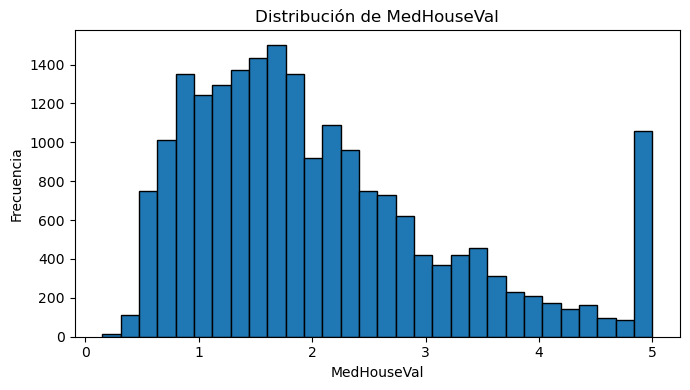

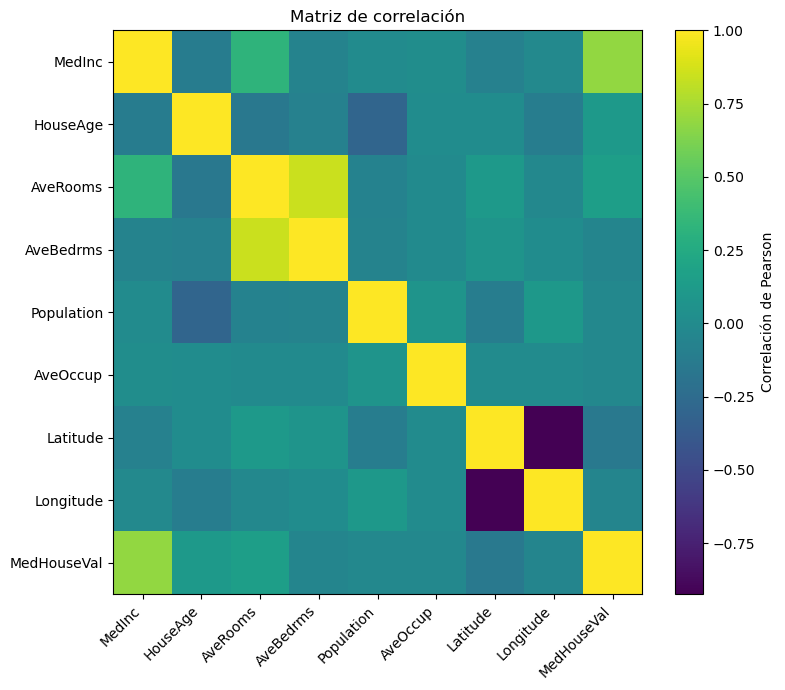

In [5]:
estadisticos = df.describe().T
display(estadisticos)
estadisticos.to_csv(OUT_DIR / 'estadisticos_descriptivos.csv')

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df[TARGET], bins=30, edgecolor='black')
ax.set_xlabel(TARGET)
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de MedHouseVal')
fig.tight_layout()
fig.savefig(FIG_DIR / 'distribucion_medhouseval.png', dpi=180, bbox_inches='tight')
plt.show()

corr_eda = df.corr(numeric_only=True)
corr_eda.to_csv(OUT_DIR / 'matriz_correlacion_eda.csv')

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr_eda.values, aspect='auto')
ax.set_xticks(range(len(corr_eda.columns)))
ax.set_xticklabels(corr_eda.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr_eda.index)))
ax.set_yticklabels(corr_eda.index)
ax.set_title('Matriz de correlación')
fig.colorbar(im, ax=ax, label='Correlación de Pearson')
fig.tight_layout()
fig.savefig(FIG_DIR / 'correlacion_eda.png', dpi=180, bbox_inches='tight')
plt.show()

### 3.5 Partición entrenamiento/prueba

Se utiliza 80% de las observaciones para entrenamiento y 20% para prueba. El conjunto de prueba permanece fuera de la selección de variables y del ajuste del escalador.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

resumen_split = pd.DataFrame({
    'Objeto': ['X', 'y', 'X_train', 'X_test', 'y_train', 'y_test'],
    'Dimension': [
        str(X.shape),
        str(y.shape),
        str(X_train.shape),
        str(X_test.shape),
        str(y_train.shape),
        str(y_test.shape),
    ],
})

display(resumen_split)

assert len(X_train) + len(X_test) == len(X)
assert set(X_train.index).isdisjoint(set(X_test.index))

resumen_split.to_csv(OUT_DIR / 'dimensiones_split.csv', index=False)

,Objeto,Dimension
0,X,"(20640, 8)"
1,y,"(20640,)"
2,X_train,"(16512, 8)"
3,X_test,"(4128, 8)"
4,y_train,"(16512,)"
5,y_test,"(4128,)"


### 3.6 Selección de variables

Para la regresión lineal simple se selecciona un único predictor mediante la correlación de Pearson calculada solo en el conjunto de entrenamiento.

In [7]:
correlaciones_train = (
    X_train.assign(MedHouseVal=y_train)
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=lambda serie: serie.abs(), ascending=False)
    .rename('Correlacion_Pearson_train')
    .to_frame()
)

display(correlaciones_train)

SIMPLE_FEATURE = correlaciones_train.index[0]
print('Predictor seleccionado:', SIMPLE_FEATURE)

correlaciones_train.to_csv(OUT_DIR / 'correlaciones_entrenamiento.csv')

,Correlacion_Pearson_train
MedInc,0.690647
AveRooms,0.158485
Latitude,-0.142983
HouseAge,0.103706
AveBedrms,-0.051351
Longitude,-0.046349
Population,-0.026032
AveOccup,-0.022030


Predictor seleccionado: MedInc


### 3.7 Estandarización

`StandardScaler` se ajusta exclusivamente con `X_train` y luego se aplica a los conjuntos de entrenamiento y prueba.

In [8]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=FEATURES,
    index=X_train.index,
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=FEATURES,
    index=X_test.index,
)

parametros_scaler = pd.DataFrame({
    'Variable': FEATURES,
    'Media_aprendida_train': scaler.mean_,
    'Escala_aprendida_train': scaler.scale_,
})

display(X_train_scaled.head(3))
display(parametros_scaler)

parametros_scaler.to_csv(OUT_DIR / 'parametros_standard_scaler.csv', index=False)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,-0.326196,0.348490,-0.174916,-0.208365,0.768276,0.051376,-1.372811,1.272587
8267,-0.035843,1.618118,-0.402835,-0.128530,-0.098901,-0.117362,-0.876696,0.709162
17445,0.144701,-1.952710,0.088216,-0.257538,-0.449818,-0.032280,-0.460146,-0.447603


,Variable,Media_aprendida_train,Escala_aprendida_train
0,MedInc,3.880754,1.904236
1,HouseAge,28.608285,12.602118
2,AveRooms,5.435235,2.387303
3,AveBedrms,1.096685,0.433201
4,Population,1426.453004,1137.021948
5,AveOccup,3.096961,11.578394
6,Latitude,35.643149,2.136601
7,Longitude,-119.582290,2.005593


## 4. Modelo de regresión lineal simple

La regresión lineal simple utiliza un único predictor:

\[
\hat{y}=\beta_0+\beta_1X
\]

El predictor seleccionado se toma de la matriz estandarizada de entrenamiento y se aplica sobre la matriz estandarizada de prueba.

,Elemento,Valor
0,Estimador,LinearRegression
1,Predictor,MedInc
2,Preprocesamiento,StandardScaler ajustado con X_train
3,Objetivo,MedHouseVal
4,Intercepto,2.071947
5,Coeficiente,0.79852


MSE : 0.709116
RMSE: 0.842090
R²  : 0.458859
Primeras 5 predicciones: [1.149589 1.506069 1.903937 2.850594 2.006633]


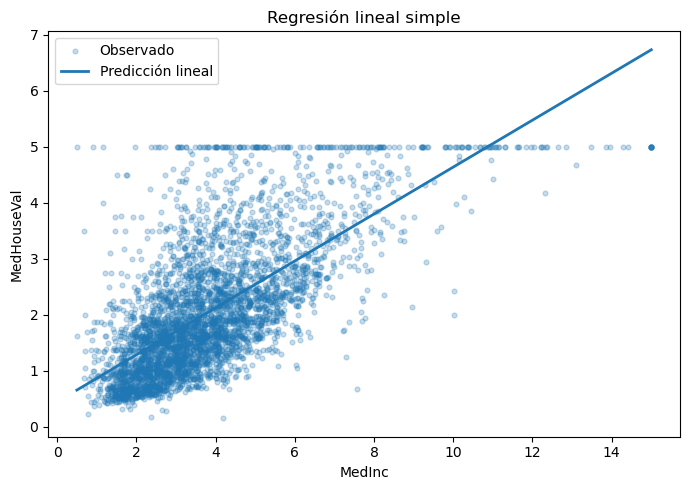

In [9]:
X_train_simple = X_train_scaled[[SIMPLE_FEATURE]]
X_test_simple = X_test_scaled[[SIMPLE_FEATURE]]

modelo_lineal_simple = LinearRegression()
modelo_lineal_simple.fit(X_train_simple, y_train)

pred_simple_train = modelo_lineal_simple.predict(X_train_simple)
pred_simple_test = modelo_lineal_simple.predict(X_test_simple)

mse_simple = mean_squared_error(y_test, pred_simple_test)
rmse_simple = np.sqrt(mse_simple)
r2_simple = r2_score(y_test, pred_simple_test)

ficha_lineal_simple = pd.DataFrame([
    ['Estimador', 'LinearRegression'],
    ['Predictor', SIMPLE_FEATURE],
    ['Preprocesamiento', 'StandardScaler ajustado con X_train'],
    ['Objetivo', TARGET],
    ['Intercepto', modelo_lineal_simple.intercept_],
    ['Coeficiente', modelo_lineal_simple.coef_[0]],
], columns=['Elemento', 'Valor'])

display(ficha_lineal_simple)
print(f'MSE : {mse_simple:.6f}')
print(f'RMSE: {rmse_simple:.6f}')
print(f'R²  : {r2_simple:.6f}')
print('Primeras 5 predicciones:', np.round(pred_simple_test[:5], 6))

ficha_lineal_simple.to_csv(
    OUT_DIR / 'ficha_tecnica_regresion_lineal_simple.csv',
    index=False,
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_test[SIMPLE_FEATURE], y_test, alpha=0.25, s=12, label='Observado')
orden = np.argsort(X_test[SIMPLE_FEATURE].to_numpy())
ax.plot(
    X_test[SIMPLE_FEATURE].to_numpy()[orden],
    pred_simple_test[orden],
    linewidth=2,
    label='Predicción lineal',
)
ax.set_xlabel(SIMPLE_FEATURE)
ax.set_ylabel(TARGET)
ax.set_title('Regresión lineal simple')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'regresion_lineal_simple.png', dpi=180, bbox_inches='tight')
plt.show()

### 4.1 Regresión lineal multivariable complementaria

Se ajusta adicionalmente `LinearRegression` con los ocho predictores estandarizados. Este resultado se conserva como referencia complementaria para la comparación entre familias de modelos.

In [10]:
modelo_lineal_multi = LinearRegression()
modelo_lineal_multi.fit(X_train_scaled, y_train)

pred_multi_train = modelo_lineal_multi.predict(X_train_scaled)
pred_multi_test = modelo_lineal_multi.predict(X_test_scaled)

mse_multi = mean_squared_error(y_test, pred_multi_test)
rmse_multi = np.sqrt(mse_multi)
r2_multi = r2_score(y_test, pred_multi_test)

print(f'MSE : {mse_multi:.6f}')
print(f'RMSE: {rmse_multi:.6f}')
print(f'R²  : {r2_multi:.6f}')
print('Primeras 5 predicciones:', np.round(pred_multi_test[:5], 6))

MSE : 0.555892
RMSE: 0.745581
R²  : 0.575788
Primeras 5 predicciones: [0.719123 1.764017 2.709659 2.838926 2.604657]


## 5. Modelo de árbol de decisión para regresión

`DecisionTreeRegressor` divide recursivamente el espacio de predictores. Se utiliza una profundidad máxima de 5 y se registran los parámetros principales de la configuración.

In [11]:
modelo_arbol = DecisionTreeRegressor(
    criterion='squared_error',
    splitter='best',
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=RANDOM_STATE,
)

modelo_arbol.fit(X_train_scaled, y_train)

pred_arbol_train = modelo_arbol.predict(X_train_scaled)
pred_arbol_test = modelo_arbol.predict(X_test_scaled)

mse_arbol = mean_squared_error(y_test, pred_arbol_test)
rmse_arbol = np.sqrt(mse_arbol)
r2_arbol = r2_score(y_test, pred_arbol_test)

ficha_arbol = pd.DataFrame([
    ['criterion', modelo_arbol.criterion],
    ['splitter', modelo_arbol.splitter],
    ['max_depth', modelo_arbol.max_depth],
    ['min_samples_split', modelo_arbol.min_samples_split],
    ['min_samples_leaf', modelo_arbol.min_samples_leaf],
    ['random_state', RANDOM_STATE],
    ['Preprocesamiento', 'StandardScaler ajustado con X_train'],
    ['Objetivo', TARGET],
], columns=['Elemento', 'Valor'])

display(ficha_arbol)
print(f'MSE : {mse_arbol:.6f}')
print(f'RMSE: {rmse_arbol:.6f}')
print(f'R²  : {r2_arbol:.6f}')
print('Primeras 5 predicciones:', np.round(pred_arbol_test[:5], 6))

ficha_arbol.to_csv(OUT_DIR / 'ficha_tecnica_arbol.csv', index=False)

,Elemento,Valor
0,criterion,squared_error
1,splitter,best
2,max_depth,5
3,min_samples_split,2
4,min_samples_leaf,1
5,random_state,42
6,Preprocesamiento,StandardScaler ajustado con X_train
7,Objetivo,MedHouseVal


MSE : 0.524515
RMSE: 0.724234
R²  : 0.599732
Primeras 5 predicciones: [1.168573 1.271581 3.199582 2.204763 1.642797]


## 6. Modelo de red neuronal para regresión

`MLPRegressor` se configura con una capa oculta de 100 neuronas, activación ReLU, optimizador Adam y detención temprana. Las ocho variables de entrada corresponden a los predictores estandarizados.

In [12]:
modelo_mlp = MLPRegressor(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=10,
    random_state=RANDOM_STATE,
)

modelo_mlp.fit(X_train_scaled, y_train)

pred_mlp_train = modelo_mlp.predict(X_train_scaled)
pred_mlp_test = modelo_mlp.predict(X_test_scaled)

mse_mlp = mean_squared_error(y_test, pred_mlp_test)
rmse_mlp = np.sqrt(mse_mlp)
r2_mlp = r2_score(y_test, pred_mlp_test)

ficha_mlp = pd.DataFrame([
    ['hidden_layer_sizes', str(modelo_mlp.hidden_layer_sizes)],
    ['activation', modelo_mlp.activation],
    ['solver', modelo_mlp.solver],
    ['alpha', modelo_mlp.alpha],
    ['learning_rate_init', modelo_mlp.learning_rate_init],
    ['max_iter', modelo_mlp.max_iter],
    ['early_stopping', modelo_mlp.early_stopping],
    ['validation_fraction', modelo_mlp.validation_fraction],
    ['n_iter_no_change', modelo_mlp.n_iter_no_change],
    ['random_state', RANDOM_STATE],
    ['Preprocesamiento', 'StandardScaler ajustado con X_train'],
    ['Objetivo', TARGET],
], columns=['Elemento', 'Valor'])

display(ficha_mlp)
print('Iteraciones realizadas:', modelo_mlp.n_iter_)
print(f'MSE : {mse_mlp:.6f}')
print(f'RMSE: {rmse_mlp:.6f}')
print(f'R²  : {r2_mlp:.6f}')
print('Primeras 5 predicciones:', np.round(pred_mlp_test[:5], 6))

ficha_mlp.to_csv(OUT_DIR / 'ficha_tecnica_mlp.csv', index=False)

,Elemento,Valor
0,hidden_layer_sizes,"(100,)"
1,activation,relu
2,solver,adam
3,alpha,0.0001
4,learning_rate_init,0.001
5,max_iter,500
6,early_stopping,True
7,validation_fraction,0.1
8,n_iter_no_change,10
9,random_state,42


Iteraciones realizadas: 153
MSE : 0.301732
RMSE: 0.549301
R²  : 0.769742
Primeras 5 predicciones: [0.37469  1.174805 4.754145 2.547741 2.916866]


## 7. Evaluación de modelos de regresión

Las métricas se calculan sobre el mismo conjunto de prueba.

\[
MSE=\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
\]

\[
RMSE=\sqrt{MSE}
\]

\[
R^2=1-\frac{SS_{res}}{SS_{tot}}
\]

La tabla principal reúne regresión lineal simple, árbol de decisión y MLP. La tabla complementaria reemplaza la regresión simple por la regresión lineal multivariable.

In [13]:
metricas_modelos = pd.DataFrame({
    'Modelo': [
        f'Regresión lineal simple ({SIMPLE_FEATURE})',
        'Árbol de decisión',
        'Red neuronal MLP',
    ],
    'MSE': [mse_simple, mse_arbol, mse_mlp],
    'RMSE': [rmse_simple, rmse_arbol, rmse_mlp],
    'R2': [r2_simple, r2_arbol, r2_mlp],
})

metricas_complementarias = pd.DataFrame({
    'Modelo': [
        'Regresión lineal multivariable',
        'Árbol de decisión',
        'Red neuronal MLP',
    ],
    'MSE': [mse_multi, mse_arbol, mse_mlp],
    'RMSE': [rmse_multi, rmse_arbol, rmse_mlp],
    'R2': [r2_multi, r2_arbol, r2_mlp],
})

print('Métricas de los modelos principales')
display(metricas_modelos.round(6))

print('Métricas de la comparación complementaria')
display(metricas_complementarias.round(6))

metricas_modelos.to_csv(OUT_DIR / 'metricas_modelos.csv', index=False)
metricas_complementarias.to_csv(
    OUT_DIR / 'metricas_comparacion_complementaria.csv',
    index=False,
)

Métricas de los modelos principales


,Modelo,MSE,RMSE,R2
0,Regresión lineal simple (MedInc),0.709116,0.842090,0.458859
1,Árbol de decisión,0.524515,0.724234,0.599732
2,Red neuronal MLP,0.301732,0.549301,0.769742


Métricas de la comparación complementaria


,Modelo,MSE,RMSE,R2
0,Regresión lineal multivariable,0.555892,0.745581,0.575788
1,Árbol de decisión,0.524515,0.724234,0.599732
2,Red neuronal MLP,0.301732,0.549301,0.769742


### 7.1 Predicciones de prueba

Se presenta una muestra de cinco observaciones del conjunto de prueba y se exportan las predicciones completas.

In [14]:
primeras_predicciones = pd.DataFrame({
    'y_real': y_test.iloc[:5].to_numpy(),
    'pred_lineal_simple': pred_simple_test[:5],
    'pred_arbol': pred_arbol_test[:5],
    'pred_mlp': pred_mlp_test[:5],
}, index=y_test.index[:5])

display(primeras_predicciones.round(6))

predicciones_test = pd.DataFrame({
    'y_real': y_test.to_numpy(),
    'pred_lineal_simple': pred_simple_test,
    'pred_lineal_multivariable': pred_multi_test,
    'pred_arbol': pred_arbol_test,
    'pred_mlp': pred_mlp_test,
}, index=y_test.index)

predicciones_test.index.name = 'indice_original'
predicciones_test.to_csv(OUT_DIR / 'predicciones_test.csv')

,y_real,pred_lineal_simple,pred_arbol,pred_mlp
20046,0.47700,1.149589,1.168573,0.374690
3024,0.45800,1.506069,1.271581,1.174805
15663,5.00001,1.903937,3.199582,4.754145
20484,2.18600,2.850594,2.204763,2.547741
9814,2.78000,2.006633,1.642797,2.916866


### 7.2 Comparación entrenamiento/prueba

Se calculan RMSE y R² en entrenamiento y prueba para disponer de una referencia adicional del comportamiento de generalización.

In [15]:
def resumen_generalizacion(nombre, y_train_real, pred_train, y_test_real, pred_test):
    return {
        'Modelo': nombre,
        'RMSE_train': np.sqrt(mean_squared_error(y_train_real, pred_train)),
        'RMSE_test': np.sqrt(mean_squared_error(y_test_real, pred_test)),
        'R2_train': r2_score(y_train_real, pred_train),
        'R2_test': r2_score(y_test_real, pred_test),
    }

generalizacion = pd.DataFrame([
    resumen_generalizacion(
        'Regresión lineal simple',
        y_train,
        pred_simple_train,
        y_test,
        pred_simple_test,
    ),
    resumen_generalizacion(
        'Regresión lineal multivariable',
        y_train,
        pred_multi_train,
        y_test,
        pred_multi_test,
    ),
    resumen_generalizacion(
        'Árbol de decisión',
        y_train,
        pred_arbol_train,
        y_test,
        pred_arbol_test,
    ),
    resumen_generalizacion(
        'Red neuronal MLP',
        y_train,
        pred_mlp_train,
        y_test,
        pred_mlp_test,
    ),
])

generalizacion['Gap_R2_train_test'] = (
    generalizacion['R2_train'] - generalizacion['R2_test']
)

display(generalizacion.round(6))
generalizacion.to_csv(OUT_DIR / 'diagnostico_generalizacion.csv', index=False)

,Modelo,RMSE_train,RMSE_test,R2_train,R2_test,Gap_R2_train_test
0,Regresión lineal simple,0.836149,0.842090,0.476993,0.458859,0.018134
1,Regresión lineal multivariable,0.719676,0.745581,0.612551,0.575788,0.036763
2,Árbol de decisión,0.695948,0.724234,0.637679,0.599732,0.037947
3,Red neuronal MLP,0.530054,0.549301,0.789825,0.769742,0.020083


## 8. Comparación de modelos

Se generan visualizaciones de las métricas, valores observados versus predichos y residuos. El ordenamiento final utiliza menor MSE, menor RMSE y mayor R².

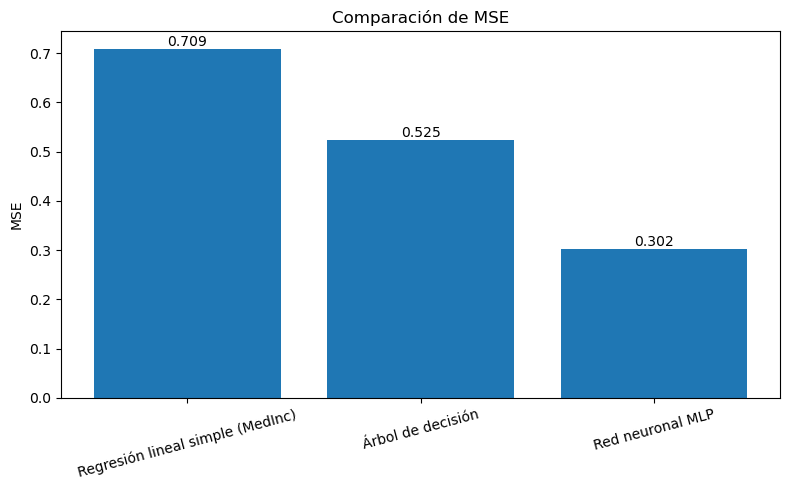

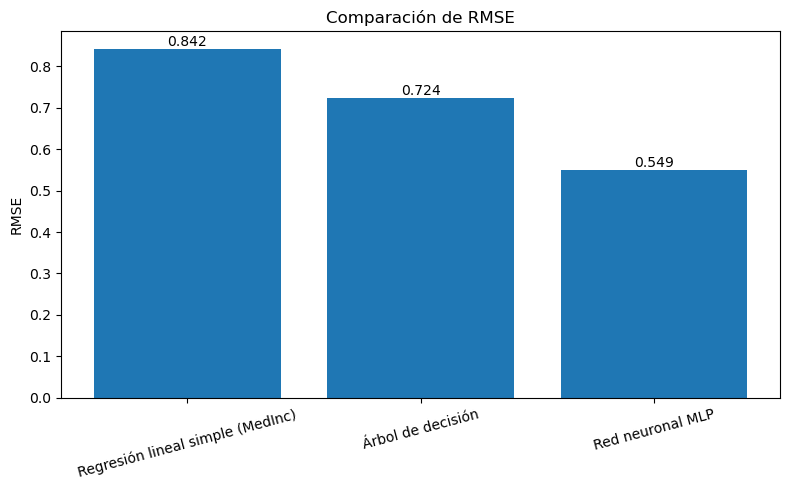

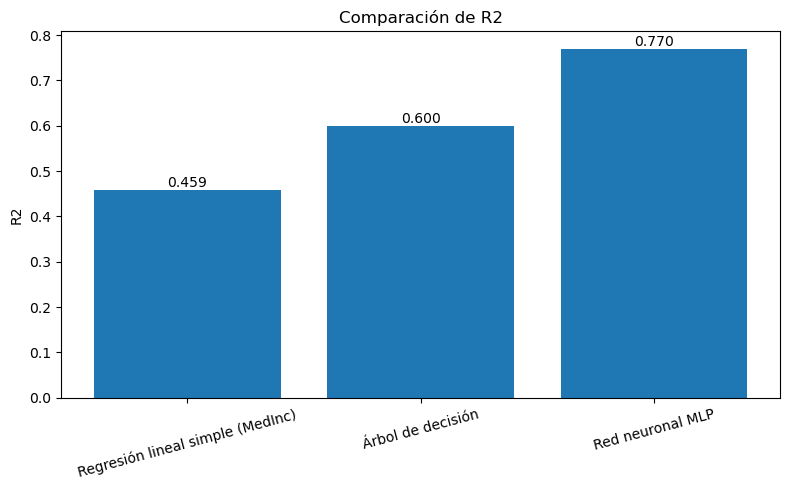

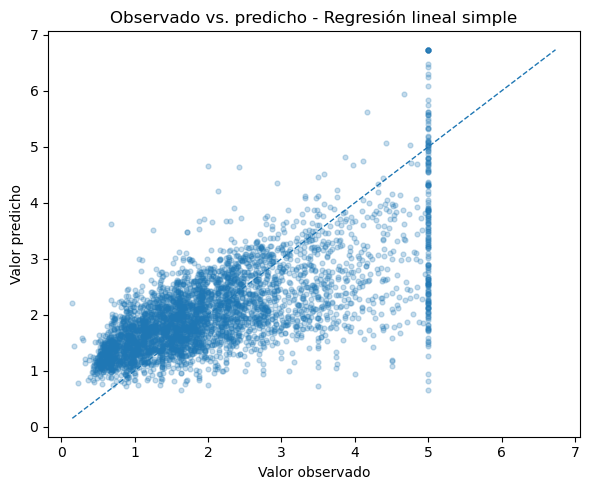

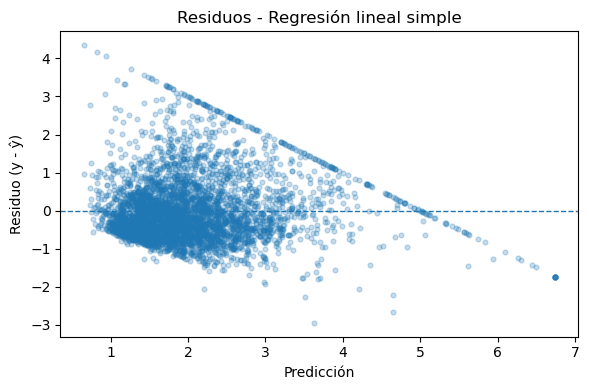

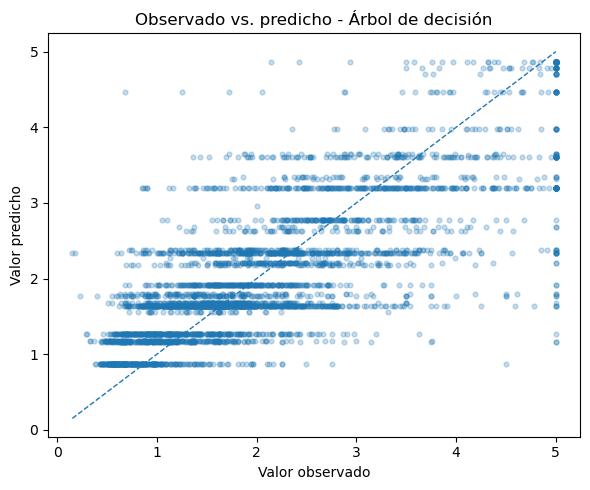

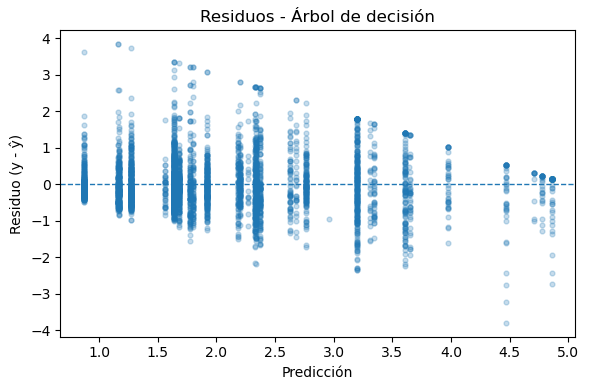

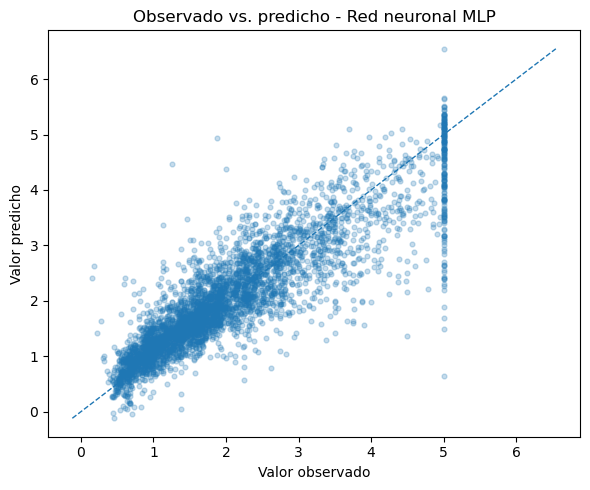

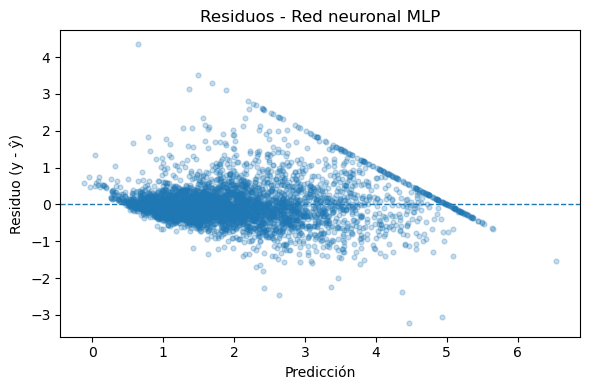

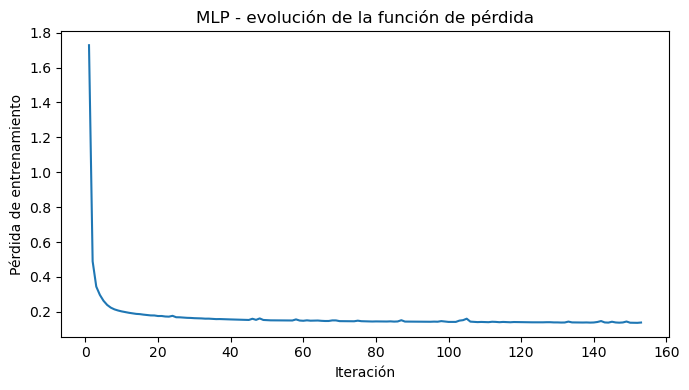

,Modelo,MSE,RMSE,R2
0,Red neuronal MLP,0.301732,0.549301,0.769742
1,Árbol de decisión,0.524515,0.724234,0.599732
2,Regresión lineal simple (MedInc),0.709116,0.842090,0.458859


,Modelo,MSE,RMSE,R2
0,Red neuronal MLP,0.301732,0.549301,0.769742
1,Árbol de decisión,0.524515,0.724234,0.599732
2,Regresión lineal multivariable,0.555892,0.745581,0.575788


In [16]:
for metrica in ['MSE', 'RMSE', 'R2']:
    fig, ax = plt.subplots(figsize=(8, 5))
    barras = ax.bar(metricas_modelos['Modelo'], metricas_modelos[metrica])
    ax.set_title(f'Comparación de {metrica}')
    ax.set_ylabel(metrica)
    ax.tick_params(axis='x', rotation=15)

    for barra, valor in zip(barras, metricas_modelos[metrica]):
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            barra.get_height(),
            f'{valor:.3f}',
            ha='center',
            va='bottom',
        )

    fig.tight_layout()
    fig.savefig(
        FIG_DIR / f'comparacion_{metrica.lower()}.png',
        dpi=180,
        bbox_inches='tight',
    )
    plt.show()

predicciones_por_modelo = {
    'Regresión lineal simple': pred_simple_test,
    'Árbol de decisión': pred_arbol_test,
    'Red neuronal MLP': pred_mlp_test,
}

for nombre, predicciones in predicciones_por_modelo.items():
    nombre_archivo = (
        nombre.lower()
        .replace(' ', '_')
        .replace('ó', 'o')
        .replace('í', 'i')
        .replace('á', 'a')
    )

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(y_test, predicciones, alpha=0.25, s=12)
    limite_min = min(float(y_test.min()), float(np.min(predicciones)))
    limite_max = max(float(y_test.max()), float(np.max(predicciones)))
    ax.plot([limite_min, limite_max], [limite_min, limite_max], '--', linewidth=1)
    ax.set_xlabel('Valor observado')
    ax.set_ylabel('Valor predicho')
    ax.set_title(f'Observado vs. predicho - {nombre}')
    fig.tight_layout()
    fig.savefig(
        FIG_DIR / f'observado_predicho_{nombre_archivo}.png',
        dpi=180,
        bbox_inches='tight',
    )
    plt.show()

    residuos = y_test.to_numpy() - predicciones
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(predicciones, residuos, alpha=0.25, s=12)
    ax.axhline(0, linestyle='--', linewidth=1)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Residuo (y - ŷ)')
    ax.set_title(f'Residuos - {nombre}')
    fig.tight_layout()
    fig.savefig(
        FIG_DIR / f'residuos_{nombre_archivo}.png',
        dpi=180,
        bbox_inches='tight',
    )
    plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(
    np.arange(1, len(modelo_mlp.loss_curve_) + 1),
    modelo_mlp.loss_curve_,
)
ax.set_xlabel('Iteración')
ax.set_ylabel('Pérdida de entrenamiento')
ax.set_title('MLP - evolución de la función de pérdida')
fig.tight_layout()
fig.savefig(FIG_DIR / 'mlp_curva_perdida.png', dpi=180, bbox_inches='tight')
plt.show()

if getattr(modelo_mlp, 'validation_scores_', None) is not None:
    validacion_mlp = pd.DataFrame({
        'Iteracion': np.arange(1, len(modelo_mlp.validation_scores_) + 1),
        'Validation_score': modelo_mlp.validation_scores_,
    })
    validacion_mlp.to_csv(OUT_DIR / 'mlp_validation_scores.csv', index=False)

orden_modelos = metricas_modelos.sort_values(
    by=['MSE', 'RMSE', 'R2'],
    ascending=[True, True, False],
).reset_index(drop=True)

orden_complementario = metricas_complementarias.sort_values(
    by=['MSE', 'RMSE', 'R2'],
    ascending=[True, True, False],
).reset_index(drop=True)

display(orden_modelos.round(6))
display(orden_complementario.round(6))

orden_modelos.to_csv(OUT_DIR / 'orden_modelos.csv', index=False)
orden_complementario.to_csv(
    OUT_DIR / 'orden_comparacion_complementaria.csv',
    index=False,
)

## 9. Referencias

James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An introduction to statistical learning: With applications in Python*. Springer. https://doi.org/10.1007/978-3-031-38747-0

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830. https://jmlr.org/papers/v12/pedregosa11a.html

Ruete, D. (2026a). *Regresión lineal simple, polinomial y multivariable* [Apunte]. Universidad Andrés Bello.

Ruete, D. (2026b). *Regresión con árboles de decisión* [Apunte]. Universidad Andrés Bello.

Ruete, D. (2026c). *Regresión con redes neuronales artificiales* [Apunte]. Universidad Andrés Bello.

Ruete, D. (2026d). *Evaluación de modelos de regresión* [Apunte]. Universidad Andrés Bello.

scikit-learn Developers. (2026a). *LinearRegression*. scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

scikit-learn Developers. (2026b). *DecisionTreeRegressor*. scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html

scikit-learn Developers. (2026c). *MLPRegressor*. scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html

scikit-learn Developers. (2026d). *train_test_split*. scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

scikit-learn Developers. (2026e). *StandardScaler*. scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html